# 01 - Matrix Calculus & Second-Order Optimization

Part of the Advanced Optimization & Numerical Methods subchapter (Mathematical Foundations). This extends the Calculus subchapter's gradient/Jacobian material (01-differentiation-gradients-jacobians) with the specific matrix-calculus identities and second-order (Hessian-based) methods that come up at companies doing heavy numerical/optimization work.

**Book reference:** *Mathematics for Machine Learning* (Deisenroth, Faisal, Ong) covers the basics used here -- §5.4 Gradients of Matrices (pp.155-158) and §5.7 Higher-Order Derivatives (pp.164-165) -- but does not have a dedicated identity reference sheet or a Newton's method treatment. The identities below follow the standard reference (Petersen & Pedersen, *The Matrix Cookbook*, free online) and Newton's method follows the standard treatment in Nocedal & Wright, *Numerical Optimization*.

# Part A - Matrix Calculus Identities, Verified Numerically

Rather than asking to trust a list of formulas, every identity below is checked against a numerical (finite-difference) gradient -- the same gradient-check technique from the Calculus subchapter.

In [1]:
import numpy as np

def numerical_grad(f, x, eps=1e-6):
    grad = np.zeros_like(x, dtype=float)
    for i in range(len(x)):
        xp, xm = x.copy(), x.copy()
        xp[i] += eps; xm[i] -= eps
        grad[i] = (f(xp) - f(xm)) / (2 * eps)
    return grad

rng = np.random.default_rng(0)
x0 = rng.normal(size=4)

### Gradient of a linear form: `d(aᵀx)/dx = a`

In [2]:
a = rng.normal(size=4)
f_linear = lambda x: a @ x
print("matches:", np.allclose(a, numerical_grad(f_linear, x0)))

matches: True


### Gradient of a quadratic form: `d(xᵀAx)/dx = (A + Aᵀ)x`  (= `2Ax` if A is symmetric)

This single identity is the one to actually memorize -- it is the gradient behind every least-squares loss, every Gaussian log-likelihood, and the Hessian derivation below.

In [3]:
A = rng.normal(size=(4, 4))
f_quad = lambda x: x @ A @ x
analytic = (A + A.T) @ x0
print("matches:", np.allclose(analytic, numerical_grad(f_quad, x0), atol=1e-4))

A_sym = A + A.T   # force symmetry
f_quad_sym = lambda x: x @ A_sym @ x
print("symmetric-A shortcut (2Ax) matches:", np.allclose(2 * A_sym @ x0, numerical_grad(f_quad_sym, x0), atol=1e-4))

matches: True
symmetric-A shortcut (2Ax) matches: True


### Gradient of a trace: `d(tr(Aᵀ X))/dX = A`, and `d(tr(XᵀAX))/dX = (A + Aᵀ)X`

Trace identities show up whenever a loss is written in matrix form (e.g. `tr(Eᵀ E)` for a matrix of residuals `E`) -- being able to convert between the trace form and the plain vector/matrix gradient is a common "derive this" interview step.

In [4]:
def numerical_grad_matrix(f, Xmat, eps=1e-6):
    grad = np.zeros_like(Xmat, dtype=float)
    it = np.nditer(Xmat, flags=["multi_index"])
    for _ in it:
        idx = it.multi_index
        Xp, Xm = Xmat.copy(), Xmat.copy()
        Xp[idx] += eps; Xm[idx] -= eps
        grad[idx] = (f(Xp) - f(Xm)) / (2 * eps)
    return grad

B = rng.normal(size=(3, 3))
X0 = rng.normal(size=(3, 3))
f_trace = lambda X: np.trace(B.T @ X)
print("d(tr(BᵀX))/dX = B, matches:", np.allclose(B, numerical_grad_matrix(f_trace, X0), atol=1e-4))

d(tr(BᵀX))/dX = B, matches: True


### Notation convention worth stating out loud in an interview

For scalar loss `L` and vector `x`, `dL/dx` (the gradient) is defined here to have the SAME shape as `x` (the "denominator layout" convention). For vector-valued `f: Rⁿ → Rᵐ`, the Jacobian `df/dx` is the `m × n` matrix from the Calculus subchapter. The Hessian, next section, is just the Jacobian of the gradient -- the gradient's own gradient.

# Part B - The Hessian

The Hessian `H` is the matrix of all second partial derivatives: `H[i,j] = ∂²f / ∂xᵢ∂xⱼ`. For any twice-differentiable function, `H` is symmetric (Clairaut's theorem: mixed partials do not depend on order). Its eigenvalues classify every stationary point (where the gradient is zero):

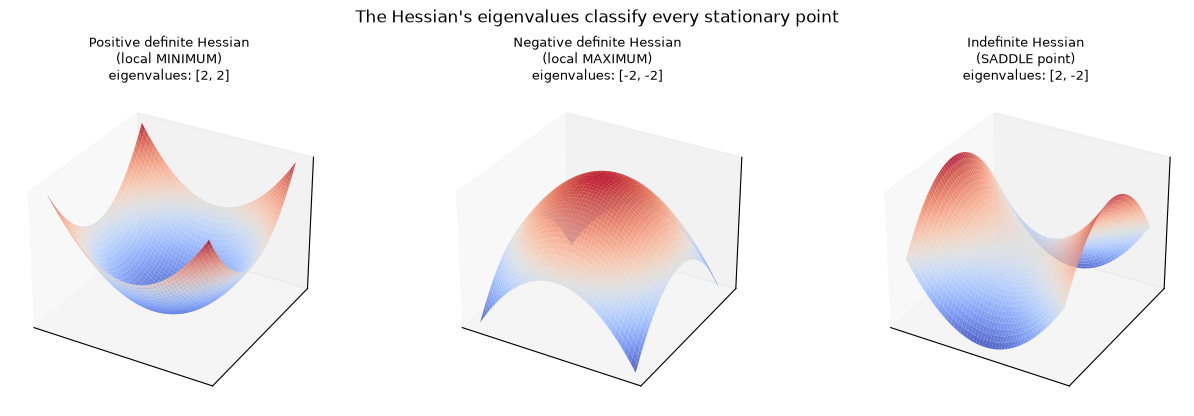

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

x = np.linspace(-3, 3, 100); y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
cases = [
    ("Positive definite Hessian\n(local MINIMUM)", X**2 + Y**2, [2, 2]),
    ("Negative definite Hessian\n(local MAXIMUM)", -(X**2 + Y**2), [-2, -2]),
    ("Indefinite Hessian\n(SADDLE point)", X**2 - Y**2, [2, -2]),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), subplot_kw={"projection": "3d"})
for ax, (title, Z, eigs) in zip(axes, cases):
    ax.plot_surface(X, Y, Z, cmap="coolwarm", alpha=0.85, linewidth=0, antialiased=True)
    ax.set_title(title + f"\neigenvalues: {eigs}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
fig.suptitle("The Hessian's eigenvalues classify every stationary point")
fig.tight_layout()
fig.savefig(FIG_DIR / "hessian_classification.png", dpi=140)
plt.show()

- **All eigenvalues positive** (positive definite) → local minimum -- curves up in every direction, exactly the picture PCA/eigendecomposition (Linear Algebra subchapter) already built intuition for, just applied to curvature instead of variance.
- **All eigenvalues negative** (negative definite) → local maximum.
- **Mixed signs** (indefinite) → saddle point -- a minimum along some directions, a maximum along others. This is the practically dominant obstacle in deep learning loss surfaces, not bad local minima (a point made in the Calculus subchapter's optimization notebook; the Hessian is what makes that claim precise).

## Connection to the second-order Taylor expansion

`f(x + Δ) ≈ f(x) + ∇f(x)ᵀΔ + ½ Δᵀ H Δ`. Gradient descent only uses the first (linear) term. Everything in the rest of this notebook comes from actually using the second (quadratic, Hessian) term.

# Part C - Newton's Method

**Derivation:** minimize the quadratic approximation above with respect to `Δ` directly -- take its gradient w.r.t. `Δ`, set to zero: `∇f(x) + HΔ = 0`, giving `Δ = -H⁻¹∇f(x)`. That is the whole method:

```
x_new = x - H⁻¹ ∇f(x)
```

Instead of stepping a fixed distance along the gradient (first-order), Newton's method uses the *curvature* to jump straight toward where the quadratic approximation's minimum actually is.

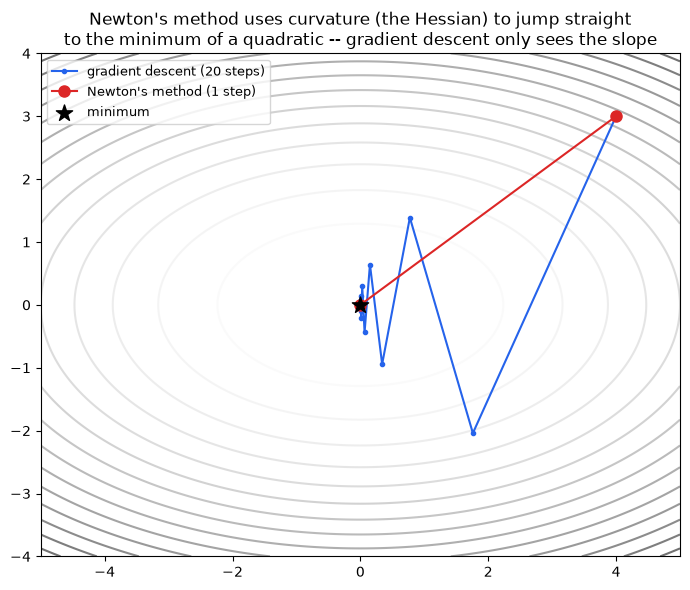

gradient descent: 20 steps  |  Newton's method: 1 step


In [6]:
def f(xy):
    x, y = xy
    return x**2 + 3 * y**2

def grad_f(xy):
    x, y = xy
    return np.array([2 * x, 6 * y])

def hess_f(xy):
    return np.array([[2., 0.], [0., 6.]])

def gd_path(start, lr, steps=20):
    path = [np.array(start, dtype=float)]
    p = np.array(start, dtype=float)
    for _ in range(steps):
        p = p - lr * grad_f(p)
        path.append(p.copy())
    return np.array(path)

def newton_path(start, steps=5):
    path = [np.array(start, dtype=float)]
    p = np.array(start, dtype=float)
    for _ in range(steps):
        p = p - np.linalg.inv(hess_f(p)) @ grad_f(p)
        path.append(p.copy())
        if np.allclose(p, 0, atol=1e-8):
            break
    return np.array(path)

xc = np.linspace(-5, 5, 200); yc = np.linspace(-4, 4, 200)
Xc, Yc = np.meshgrid(xc, yc)
Zc = Xc**2 + 3 * Yc**2

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(Xc, Yc, Zc, levels=15, cmap="Greys", alpha=0.6)
gd = gd_path([4, 3], lr=0.28)
nt = newton_path([4, 3])
ax.plot(gd[:, 0], gd[:, 1], "o-", color="#2563eb", markersize=3, label=f"gradient descent ({len(gd)-1} steps)")
ax.plot(nt[:, 0], nt[:, 1], "o-", color="#dc2626", markersize=8, label=f"Newton's method ({len(nt)-1} step)")
ax.scatter([0], [0], color="black", marker="*", s=150, zorder=5, label="minimum")
ax.legend(fontsize=9)
ax.set_title("Newton's method uses curvature (the Hessian) to jump straight\nto the minimum of a quadratic -- gradient descent only sees the slope")
fig.tight_layout()
fig.savefig(FIG_DIR / "newton_vs_gd.png", dpi=140)
plt.show()
print(f"gradient descent: {len(gd)-1} steps  |  Newton's method: {len(nt)-1} step")

**Why Newton's method converges in exactly one step here:** the function is *already* an exact quadratic, so its second-order Taylor expansion is not an approximation -- it is the function. Newton's method jumps straight to the minimum of that quadratic, which is the true minimum. For a non-quadratic function, Newton's method still converges dramatically faster near a minimum (quadratic convergence rate, vs. gradient descent's linear rate) because locally, any smooth function looks approximately quadratic.

## Why Newton's method is not used to train neural networks

Two hard costs, both from needing the full Hessian:
- **Computing it**: `O(n²)` entries for `n` parameters.
- **Inverting it**: `O(n³)`.

For a model with even a few million parameters, `n³` is completely infeasible -- this is precisely why deep learning relies on first-order methods (SGD, Adam, next notebook) or, occasionally, *quasi-Newton* methods (L-BFGS) that approximate the Hessian's effect using only gradient history, without ever forming or inverting the full matrix.

There is also a correctness caveat, not just a cost one: plain Newton's method seeks any stationary point (`∇f = 0`), including saddle points and maxima, not specifically minima -- on a non-convex surface it can be attracted to a saddle just as readily as gradient descent can slow down near one, which is part of why naive second-order methods are not a strict upgrade on non-convex deep learning loss surfaces.

## Self-check before moving on

- [ ] I can state and numerically verify the gradient of a quadratic form `xᵀAx`
- [ ] I can define the Hessian and explain why it is symmetric
- [ ] I can classify a stationary point as a min/max/saddle from the signs of the Hessian's eigenvalues
- [ ] I can derive Newton's update rule from the second-order Taylor expansion
- [ ] I can explain why Newton's method is impractical for large neural networks, in terms of `O(n²)`/`O(n³)` cost
- [ ] I know Newton's method is not guaranteed to move toward a minimum on non-convex surfaces

Next: `02-adam-and-modern-optimizers.ipynb`